In [60]:
# Import necessary libraries
from urllib.parse import urlparse, parse_qs
from google_play_scraper import reviews, Sort
import pandas as pd

In [61]:
# Function to extract package name from Google Play URL
def get_package_name(play_store_url):
    parsed_url = urlparse(play_store_url)
    query_params = parse_qs(parsed_url.query)
    return query_params.get('id', [None])[0]

# Define Google Play Store URL
url = "https://play.google.com/store/apps/details?id=com.gryphline.endfield.gp&hl=id"

# Extract package name
package_name = get_package_name(url)
print("Extracted Package Name:", package_name)

Extracted Package Name: com.gryphline.endfield.gp


In [62]:
# Fetch reviews using the extracted package name
app_reviews, _ = reviews(
    package_name,
    lang='id',   # Language: English
    country='id',  # Country: US
    count=1000,   # Fetch 200 reviews to allow filtering
    sort= Sort.NEWEST  # Get the latest reviews
)

# Convert reviews to a DataFrame
df = pd.DataFrame(app_reviews)

# Display
df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,6fc6686e-5bd2-453b-8ba7-95fb279b4888,Vino Vinoo,https://play-lh.googleusercontent.com/a-/ALV-U...,buat dowload data kecepatan dowload nya kok di...,1,0,1.2.5,2026-05-03 13:22:08,NaN,NaT,1.2.5
1,7fb596e9-621f-4737-a49d-818cd1f21e40,R,https://play-lh.googleusercontent.com/a/ACg8oc...,game baik 👍,5,0,1.2.5,2026-05-03 09:18:55,NaN,NaT,1.2.5
2,1bee5182-b360-46d1-a3a4-27c407571eaa,Freedom Killer,https://play-lh.googleusercontent.com/a-/ALV-U...,best pabrik game,5,0,NaN,2026-05-03 08:52:45,NaN,NaT,NaN
3,47472df2-4906-4ef0-b148-bf9e3979c3a2,Yudhistira Yossa Adirajasa,https://play-lh.googleusercontent.com/a-/ALV-U...,Bagusnya: - Desain Karakter mantap - Desain Vi...,2,0,NaN,2026-05-03 03:05:58,NaN,NaT,NaN
4,7683f57e-3b71-4d4b-96b0-aad2fcc3852a,Ariel,https://play-lh.googleusercontent.com/a-/ALV-U...,Story so boring that i fell asleep many times ...,4,0,1.2.5,2026-05-02 23:36:14,NaN,NaT,1.2.5
...,...,...,...,...,...,...,...,...,...,...,...
995,888f358f-c429-4253-971c-b1bf176ec269,Ariel Sanseta,https://play-lh.googleusercontent.com/a/ACg8oc...,Hari ini jam 17.00 buka gamenya akun gua di ba...,1,2,1.0.13,2026-02-09 20:22:08,NaN,NaT,1.0.13
996,576f764c-e15c-4db4-aa61-067b273276f7,Ima Jinasi,https://play-lh.googleusercontent.com/a-/ALV-U...,GAME TERBAIK SEPANJANG MASA!!,5,0,1.0.13,2026-02-09 17:58:47,NaN,NaT,1.0.13
997,bf651afa-d695-4016-84c8-ca24121c5343,Risman Sutrisna Nugraha (Riz),https://play-lh.googleusercontent.com/a-/ALV-U...,..... masih mending game sebelah ukuran nya le...,1,0,1.0.13,2026-02-09 17:27:21,Halo Endministrator!\n\nTerima kasih atassaran...,2026-03-11 10:19:52,1.0.13
998,86fc62f0-b05a-42ab-88f2-04b140e020f1,MMN 688,https://play-lh.googleusercontent.com/a-/ALV-U...,The Factory must grow,5,0,1.0.13,2026-02-09 16:26:32,NaN,NaT,1.0.13


In [63]:
# Select only the required columns: 'reviewId', 'content', and 'score'
df_filtered_columns = df[['reviewId', 'content', 'score']]

# Display the result
df_filtered_columns

,reviewId,content,score
0,6fc6686e-5bd2-453b-8ba7-95fb279b4888,buat dowload data kecepatan dowload nya kok di...,1
1,7fb596e9-621f-4737-a49d-818cd1f21e40,game baik 👍,5
2,1bee5182-b360-46d1-a3a4-27c407571eaa,best pabrik game,5
3,47472df2-4906-4ef0-b148-bf9e3979c3a2,Bagusnya: - Desain Karakter mantap - Desain Vi...,2
4,7683f57e-3b71-4d4b-96b0-aad2fcc3852a,Story so boring that i fell asleep many times ...,4
...,...,...,...
995,888f358f-c429-4253-971c-b1bf176ec269,Hari ini jam 17.00 buka gamenya akun gua di ba...,1
996,576f764c-e15c-4db4-aa61-067b273276f7,GAME TERBAIK SEPANJANG MASA!!,5
997,bf651afa-d695-4016-84c8-ca24121c5343,..... masih mending game sebelah ukuran nya le...,1
998,86fc62f0-b05a-42ab-88f2-04b140e020f1,The Factory must grow,5


In [64]:

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Mengunduh resource NLTK yang dibutuhkan (hanya perlu dijalankan sekali)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Inisialisasi lemmatizer dan daftar stopwords bahasa Inggris
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Jika teks kosong atau bukan string, kembalikan string kosong
    if not isinstance(text, str):
        return ""

    # 1. Case Folding: Mengubah teks menjadi huruf kecil semua (lowercase)
    text = text.lower()

    # 2. Menghapus URL/Link (jika ada)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Menghapus tanda baca dan karakter spesial
    text = re.sub(r'[^\w\s]', '', text)

    # 4. Menghapus angka (opsional, tapi berguna untuk analisis teks umum)
    text = re.sub(r'\d+', '', text)

    # 5. Tokenization & Stopwords Removal & Lemmatization
    # Memecah kalimat menjadi kata-kata, memfilter stopwords, lalu mengubah ke kata dasar
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    # 6. Menggabungkan kata-kata kembali menjadi satu kalimat utuh
    return ' '.join(cleaned_words)

# Menghindari peringatan SettingWithCopyWarning dari pandas
df_filtered_columns = df_filtered_columns.copy()

# Mengaplikasikan fungsi preprocessing ke kolom 'content'
df_filtered_columns['cleaned_text'] = df_filtered_columns['content'].apply(preprocess_text)

# Membuat output yang hanya berisi text asli dan cleaned text sesuai permintaan
output_df = df_filtered_columns[['content', 'cleaned_text']]

# Menampilkan 10 baris pertama dari hasilnya
output_df.head(10)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Mareko\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Mareko\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Mareko\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,content,cleaned_text
0,buat dowload data kecepatan dowload nya kok di...,buat dowload data kecepatan dowload nya kok di...
1,game baik 👍,game baik
2,best pabrik game,best pabrik game
3,Bagusnya: - Desain Karakter mantap - Desain Vi...,bagusnya desain karakter mantap desain villain...
4,Story so boring that i fell asleep many times ...,story boring fell asleep many time main quest ...
5,game ini sangat bagus bagi org yg suka alur ce...,game ini sangat bagus bagi org yg suka alur ce...
6,"gila, settingan grafik udah paling rendah masi...",gila settingan grafik udah paling rendah masih...
7,"perolehan gacha sangat buruk, harus 120 kali u...",perolehan gacha sangat buruk harus kali untuk ...
8,"kok keluar sendiri? poxo x8, game besar lain g...",kok keluar sendiri poxo x game besar lain gak ...
9,"teruntuk developer game, akhir-akhir ini saya ...",teruntuk developer game akhirakhir ini saya me...


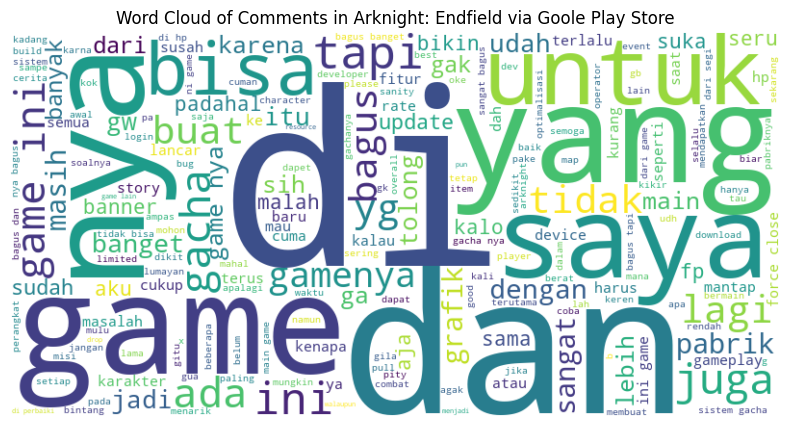

In [65]:

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all cleaned text into a single string for the word cloud
all_text = ' '.join(output_df['cleaned_text'])

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Comments in Arknight: Endfield via Goole Play Store")
plt.show()

       Word  Frequency
15     game        574
6        di        377
4       nya        358
88      dan        298
80      ini        289
12    bagus        283
94     yang        255
142    saya        225
180    bisa        196
40    gacha        186
115   untuk        176
249    tapi        170
216     ada        135
154   tidak        126
81   sangat        118
65     juga        117
13   tolong        116
172  banget        112
169    dari        108
243    lagi        105


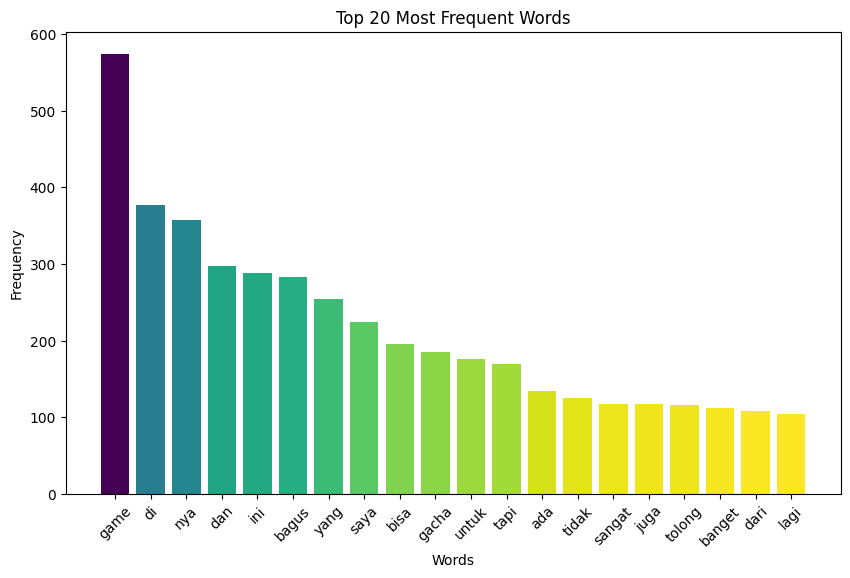

In [66]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import viridis_r
from matplotlib.colors import Normalize

# Split all cleaned text into individual words
all_words = ' '.join(output_df['cleaned_text']).split()

# Count the frequency of each word
word_counts = Counter(all_words)

# Convert the counts to a DataFrame for easier analysis
word_freq_df = pd.DataFrame(word_counts.items(), columns=['Word', 'Frequency']).sort_values(by='Frequency', ascending=False)

# Display the top 20 most frequent words
print(word_freq_df.head(20))

# Prepare inverted viridis colormap
top_words = word_freq_df.head(20)
norm = Normalize(vmin=min(top_words['Frequency']), vmax=max(top_words['Frequency']))
colors = [viridis_r(norm(value)) for value in top_words['Frequency']]

# Show a bar plot of the top 20 most frequent words with inverted viridis
plt.figure(figsize=(10, 6))
plt.bar(top_words['Word'], top_words['Frequency'], color=colors)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 20 Most Frequent Words')
plt.xticks(rotation=45)
plt.show()

In [67]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.stem.porter import PorterStemmer

# 1. Initialize the stemmer
porter = PorterStemmer()

# 2. Define the tokenizer function
def tokenizer_porter(text):
    return [porter.stem(word) for word in text.split()]

# 3. Define TF-IDF vectorizer
tfidf = TfidfVectorizer(strip_accents=None,
                        lowercase=False,
                        tokenizer=tokenizer_porter,
                        token_pattern=None,
                        use_idf=True,
                        norm='l2',
                        smooth_idf=True)

# Fit and transform your cleaned text
tfidf_matrix = tfidf.fit_transform(output_df['cleaned_text'])
print(tfidf_matrix.shape)

(1000, 3542)


In [68]:

from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Membuat kolom label 'sentiment' berdasarkan 'score'
df_filtered_columns['sentiment'] = df_filtered_columns['score'].apply(lambda x: 1 if x > 3 else 0)

# 2. Inisialisasi TF-IDF Vectorizer (menggunakan default tokenizer)
tfidf = TfidfVectorizer(strip_accents=None,
                        lowercase=False,
                        use_idf=True,
                        norm='l2',
                        smooth_idf=True)

# 3. Transformasi teks yang sudah dibersihkan (cleaned_text) menjadi matriks fitur (X)
X = tfidf.fit_transform(df_filtered_columns['cleaned_text'])

# 4. Target variabel (Y)
y = df_filtered_columns['sentiment']

print("Dimensi fitur X:", X.shape)
print("Dimensi target y:", y.shape)

Dimensi fitur X: (1000, 3595)
Dimensi target y: (1000,)


In [69]:

from sklearn.model_selection import train_test_split

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data training: {X_train.shape[0]}")
print(f"Jumlah data testing: {X_test.shape[0]}")

Jumlah data training: 800
Jumlah data testing: 200


In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Inisialisasi model Logistic Regression
model = LogisticRegression()

# 2. Melatih (Training) model menggunakan data train
model.fit(X_train, y_train)

# 3. Memprediksi data test
y_pred = model.predict(X_test)

# 4. Menghitung dan menampilkan Akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%\n")

# Menampilkan laporan klasifikasi lengkap
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Akurasi Model: 75.00%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.72      0.30      0.42        61
    Positive       0.75      0.95      0.84       139

    accuracy                           0.75       200
   macro avg       0.74      0.62      0.63       200
weighted avg       0.74      0.75      0.71       200



In [71]:

def predict_sentiment(text):
    # Preprocess teks menggunakan fungsi 'preprocess_text' yang sudah kamu buat di awal
    cleaned_input = preprocess_text(text)

    # Ubah teks ke dalam format TF-IDF
    vectorized_input = tfidf.transform([cleaned_input])

    # Lakukan prediksi
    prediction = model.predict(vectorized_input)

    # Kembalikan hasil berupa string
    return "Positive" if prediction[0] == 1 else "Negative"

# Mari kita uji dengan kalimat baru!
test_sentence_1 = "Game Baik"
test_sentence_2 = "perolehan gacha sangat buruk"

print(f"Review: '{test_sentence_1}'\nPrediksi: {predict_sentiment(test_sentence_1)}\n")
print(f"Review: '{test_sentence_2}'\nPrediksi: {predict_sentiment(test_sentence_2)}")

Review: 'Game Baik'
Prediksi: Positive

Review: 'perolehan gacha sangat buruk'
Prediksi: Positive


In [72]:

# Prediksi seluruh data matriks TF-IDF (X)
all_predictions = model.predict(X)

# Masukkan hasil prediksi ke dalam dataframe
df_filtered_columns['predicted_sentiment'] = all_predictions

# Mapping angka (1, 0) kembali menjadi teks agar mudah dibaca pada grafik nanti
df_filtered_columns['sentiment_label'] = df_filtered_columns['predicted_sentiment'].map({1: 'Positive', 0: 'Negative'})

# Tampilkan 5 baris pertama untuk mengecek hasilnya
df_filtered_columns[['content', 'score', 'sentiment_label']].head()

,content,score,sentiment_label
0,buat dowload data kecepatan dowload nya kok di...,1,Positive
1,game baik 👍,5,Positive
2,best pabrik game,5,Positive
3,Bagusnya: - Desain Karakter mantap - Desain Vi...,2,Positive
4,Story so boring that i fell asleep many times ...,4,Positive


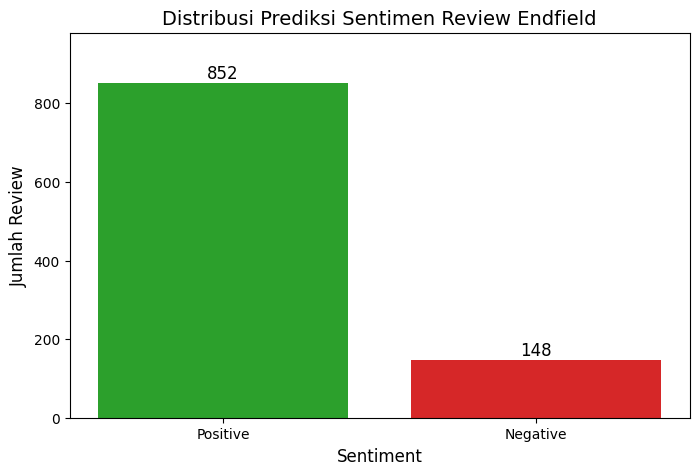

In [73]:

import matplotlib.pyplot as plt

# Hitung jumlah masing-masing sentimen
sentiment_counts = df_filtered_columns['sentiment_label'].value_counts()

# Membuat Bar Chart
plt.figure(figsize=(8, 5))
bars = plt.bar(sentiment_counts.index, sentiment_counts.values, color=['#2ca02c', '#d62728']) # Hijau & Merah

# Menambahkan judul dan label sumbu
plt.title('Distribusi Prediksi Sentimen Review Endfield', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Jumlah Review', fontsize=12)

# Menambahkan angka (label) di atas setiap bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom', fontsize=12)

# Tampilkan grafik
plt.ylim(0, max(sentiment_counts.values) + max(sentiment_counts.values)*0.15) # Memberi ruang kosong di atas bar
plt.show()